In [ ]:
"""
Visualize baseline province distribution on global maps
"""

In [1]:
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

In [2]:
sample_metadata = pd.read_csv("../data/share/sample_metadata.csv", index_col=0)
Y = sample_metadata
Y

,sample_name,sra_run,division,subdivision,bioproject,biosample,longhurst_province_code,longhurst_province_name,longhurst_province_category,instrument,collection_date,collection_depth,latitude,longitude,iho_sea,iho_sea_mrgid,iho_sea_simplified,sourmash_k_10_1487_25m,picoplankton_province
index,,,,,,,,,,,,,,,,,,,
APLR_P_0000_Arc_Ant_S07,Arc_Ant_S07,SRR10912840,NS polar,PRJNA588686,PRJNA588686,SAMN13674977,APLR,Polar - Austral Polar Province,Polar,Illumina HiSeq 2500,NaN,0.0,-76.96,173.02,Southern Ocean,1907.0,Southern Ocean,0,APLR
APLR_P_0001_Arc_Ant_S31,Arc_Ant_S31,SRR10912852,NS polar,PRJNA588686,PRJNA588686,SAMN13674977,APLR,Polar - Austral Polar Province,Polar,Illumina HiSeq 2500,NaN,0.0,-70.75,-169.00,Southern Ocean,1907.0,Southern Ocean,0,APLR
APLR_P_0002_Arc_Ant_S06,Arc_Ant_S06,SRR10912862,NS polar,PRJNA588686,PRJNA588686,SAMN13674977,APLR,Polar - Austral Polar Province,Polar,Illumina HiSeq 2500,NaN,0.0,-70.05,-112.73,Southern Ocean,1907.0,Southern Ocean,0,APLR
APLR_P_0003_Arc_Ant_S32,Arc_Ant_S32,SRR10912849,NS polar,PRJNA588686,PRJNA588686,SAMN13674977,APLR,Polar - Austral Polar Province,Polar,Illumina HiSeq 2500,NaN,0.0,-70.00,-160.08,Southern Ocean,1907.0,Southern Ocean,0,APLR
APLR_P_0004_SRX8974249,SRX8974249,SRR12480113,P18,SRP278138,PRJNA656268,SAMN15783169,APLR,Polar - Austral Polar Province,Polar,Illumina NovaSeq 6000,2017-01-28T04:45:00Z,3.0,-70.00,-100.24,Southern Ocean,1907.0,Southern Ocean,0,APLR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BPLR_P_1239_SRS2348820,SRS2348820,SRR5819754,Canada Basin,pelagic_arctic_ocean,PRJNA367429,SAMN06267280,BPLR,Polar - Boreal Polar Province (POLR),Polar,Illumina HiSeq 2500,1/10/2015,5.0,79.25,-150.06,Arctic Ocean,1906.0,Arctic Ocean,14,BPLR
BPLR_P_1241_Arc_Ant_N25,Arc_Ant_N25,SRR10912808,NS polar,PRJNA588686,PRJNA588686,SAMN13674978,BPLR,Polar - Boreal Polar Province (POLR),Polar,Illumina HiSeq 2500,NaN,0.0,80.03,179.55,Arctic Ocean,1906.0,Arctic Ocean,14,BPLR
BPLR_P_1242_Arc_Ant_N44,Arc_Ant_N44,SRR10912888,NS polar,PRJNA588686,PRJNA588686,SAMN13674978,BPLR,Polar - Boreal Polar Province (POLR),Polar,Illumina HiSeq 2500,NaN,0.0,82.05,168.01,Arctic Ocean,1906.0,Arctic Ocean,14,BPLR


In [3]:
provinces = sorted(Y["picoplankton_province"].unique())
colours = plt.cm.tab10.colors

province_colour = dict(zip(provinces, colours))

Text(0.0, 1.0, 'Sample present-day province')

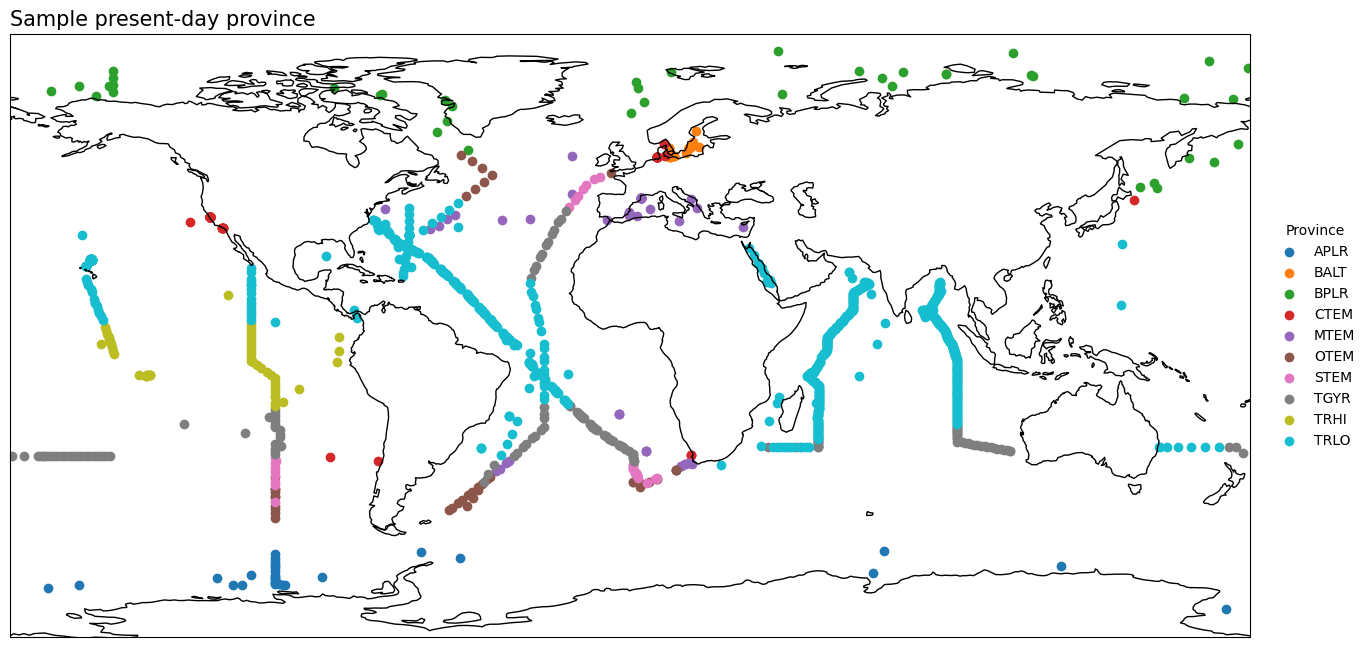

In [6]:
world_map = plt.figure(figsize=(16,8))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

for prov, df in Y.groupby("picoplankton_province"): 
    ax.scatter(
        df["longitude"],
        df["latitude"],
        color=province_colour[prov], 
        label=prov,
        transform=ccrs.PlateCarree(),
    )

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    title="Province",
)    

ax.set_title(
    "Sample present-day province", 
    size=15,
    loc="left",
)